<a href="https://colab.research.google.com/github/NethmiKaveeshaE23174/Statistical-Learning-e23174/blob/main/assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

Answer

# Part 1: General Kalman Filter Derivations

### Assumed Noise Models
For these proofs, we assume standard white Gaussian noise properties:
* Process noise: $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$
* Measurement noise: $z_k \sim \mathscr{N}(0, \Sigma_m)$
* Both $w_{k-1}$ and $z_k$ are mutually independent and independent of the states.

---

### Question 1: State Prediction Distribution
We want to show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$. Because $x_{k-1}^+$ and $w_{k-1}$ are independent Gaussian random variables, their linear combination $x_k^-$ is also Gaussian.

**1. Mean ($m_k^-$):**
$$
\begin{aligned}
m_k^- = \mathbb{E}[x_k^-] &= \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + 0 = A_{k-1}m_{k-1}
\end{aligned}
$$

**2. Covariance ($P_k^-$):**
$$
\begin{aligned}
P_k^- &= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T] \\
&= \mathbb{E}[(A_{k-1}(x_{k-1}^+ - m_{k-1}) + G_{k-1}w_{k-1})(A_{k-1}(x_{k-1}^+ - m_{k-1}) + G_{k-1}w_{k-1})^T]
\end{aligned}
$$
Since $\mathbb{E}[(x_{k-1}^+ - m_{k-1})w_{k-1}^T] = 0$, the cross-terms vanish:
$$
P_k^- = A_{k-1}\mathbb{E}[(x_{k-1}^+ - m_{k-1})(x_{k-1}^+ - m_{k-1})^T]A_{k-1}^T + G_{k-1}\mathbb{E}[w_{k-1}w_{k-1}^T]G_{k-1}^T
$$
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
$$

### Question 2: Measurement Prediction Distribution
We want to show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

**1. Mean:**
$$
\begin{aligned}
\mathbb{E}[y_k^-] &= \mathbb{E}[H_k x_k^- + z_k] \\
&= H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] \\
&= H_k m_k^- + 0 = H_k m_k^-
\end{aligned}
$$

**2. Covariance:**
$$
\begin{aligned}
\text{Var}(y_k^-) &= \mathbb{E}[(y_k^- - \mathbb{E}[y_k^-])(y_k^- - \mathbb{E}[y_k^-])^T] \\
&= \mathbb{E}[(H_k(x_k^- - m_k^-) + z_k)(H_k(x_k^- - m_k^-) + z_k)^T]
\end{aligned}
$$
Since $x_k^-$ and $z_k$ are uncorrelated, cross-terms vanish:
$$
\text{Var}(y_k^-) = H_k \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[z_k z_k^T] = H_k P_k^- H_k^T + \Sigma_m
$$

### Question 3: Joint Distribution
We seek the joint Gaussian distribution:
$$
\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & \Sigma_{xy} \\ \Sigma_{yx} & \text{Var}(y_k^-) \end{bmatrix}
\right)
$$

We only need to find the cross-covariance term $\Sigma_{xy}$:
$$
\begin{aligned}
\Sigma_{xy} &= \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T] \\
&= \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T] \\
&= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T] \\
&= P_k^- H_k^T + 0 = P_k^- H_k^T
\end{aligned}
$$
Since $\Sigma_{yx} = \Sigma_{xy}^T = H_k P_k^-$, we get:
$$
\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)
$$

### Questions 4 & 5: Conditional Update & Expectations
Using the **Gaussian Conditioning Theorem**, if:
$$
\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix} \right)
$$
Then the conditional distribution $(X \mid Y = y)$ is Gaussian with:
$$
\mathbb{E}[X \mid Y=y] = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_y)
$$
$$
\text{Var}(X \mid Y=y) = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}
$$

Substituting our joint terms from Question 3:
* $\mu_x = m_k^-$, $\mu_y = H_k m_k^-$
* $\Sigma_{xx} = P_k^-$, $\Sigma_{xy} = P_k^- H_k^T$, $\Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m$

Let $K_k = \Sigma_{xy}\Sigma_{yy}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$.

**Answer to Question 5:**
$$
\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)
$$
$$
\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-
$$

**Answer to Question 4:**
Since these match $m_k$ and $P_k$ exactly, $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k)$.

# Part 2: Scalar Linear-Gaussian Model Derivations

For the scalar model, we set $A_{k-1} = a$, $G_{k-1} = 1$, $\Sigma_p = q$, $H_k = h$, and $\Sigma_m = r$.

### Question 1: Scalar Prediction
Substituting the scalar values into the general equations from Part 1:
$$
m_k^- = a \cdot m_{k-1}
$$
$$
P_k^- = a \cdot P_{k-1} \cdot a + 1 \cdot q \cdot 1 = a^2 P_{k-1} + q
$$

### Question 2: Scalar Update
Define the measurement residual covariance scalar as $S_k = h^2 P_k^- + r$.
The scalar Kalman gain becomes:
$$
K_k = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}
$$

Thus, the updated mean and variance expressions match perfectly:
$$
m_k = m_k^- + K_k\,v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)
$$
$$
P_k = (1 - K_k h)\,P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-
$$

### Question 3: Predictive Measurement Distribution
Before incorporating the actual value $y_k$, the prediction $y_k^-$ depends strictly on the predicted state $x_k^-$. From Part 1 Question 2, substituting scalar parameters directly yields:
$$
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)
$$

### Question 4: Posterior-Predictive Measurement Distribution
After filtering/updating the state to $x_k \sim \mathscr{N}(m_k, P_k)$, a hypothetical re-evaluation of the measurement equation gives:
$$
\mathbb{E}[y_k^- \mid Y_k] = h \mathbb{E}[x_k \mid Y_k] = h m_k
$$
$$
\text{Var}(y_k^- \mid Y_k) = h^2 \text{Var}(x_k \mid Y_k) + r = h^2 P_k + r
$$
$$
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# 1. Setup parameters for the Scalar Linear-Gaussian Model
np.random.seed(42)
T = 20  # Total time steps
a = 0.95
head_h = 1.0  # h parameter
q = 0.15
r = 0.25

# Generate true states and observed measurements
x_true = np.zeros(T)
y_obs = np.zeros(T)
x_true[0] = 0.5 + np.random.normal(0, np.sqrt(0.1))

for k in range(1, T):
    x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = head_h * x_true[k] + np.random.normal(0, np.sqrt(r))

# 2. Run Kalman Filter tracking history for tracking steps
m = 0.0
P = 1.0

m_prior_hist = []
P_prior_hist = []
m_post_hist = []
P_post_hist = []

for k in range(T):
    # Predict step
    if k == 0:
        m_f_minus = m
        P_f_minus = P
    else:
        m_f_minus = a * m
        P_f_minus = a**2 * P + q

    # Update step
    S_k = head_h**2 * P_f_minus + r
    K_k = (P_f_minus * head_h) / S_k
    m = m_f_minus + K_k * (y_obs[k] - head_h * m_f_minus)
    P = (1 - K_k * head_h) * P_f_minus

    m_prior_hist.append(m_f_minus)
    P_prior_hist.append(P_f_minus)
    m_post_hist.append(m)
    P_post_hist.append(P)

# 3. Setup Animation Plotting Framework
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-4, 4, 500)

line_prior, = ax.plot([], [], 'r-', lw=2.5, label='Prior Distribution $p(x_k \\mid Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', lw=2.5, label='Posterior Distribution $p(x_k \\mid Y_k)$')
v_line_true = ax.axvline(0, color='green', linestyle='--', alpha=0.7, label='True State ($x_k$)')
v_line_obs = ax.axvline(0, color='purple', linestyle=':', alpha=0.7, label='Observed Measurement ($y_k$)')

ax.set_xlim(-4, 4)
ax.set_ylim(0, 1.8)
ax.set_xlabel('State Space / Domain', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Kalman Filter Transitions: Prior vs. Posterior Distributions', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_post

def update(k):
    # Calculate density curves
    y_prior = norm.pdf(x_axis, m_prior_hist[k], np.sqrt(P_prior_hist[k]))
    y_post = norm.pdf(x_axis, m_post_hist[k], np.sqrt(P_post_hist[k]))

    line_prior.set_data(x_axis, y_prior)
    line_post.set_data(x_axis, y_post)

    # Reposition indicator lines
    v_line_true.set_xdata([x_true[k], x_true[k]])
    v_line_obs.set_xdata([y_obs[k], y_obs[k]])

    ax.set_title(f'Kalman Filter Distributions - Time Step k = {k}', fontsize=14)
    return line_prior, line_post, v_line_true, v_line_obs

# Render out dynamic animation
anim = FuncAnimation(fig, update, frames=T, init_func=init, blit=True, interval=800)
plt.close()

# To display directly in your Colab cell notebook, run:
HTML(anim.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

Answer

# Part 3: Two-Dimensional Constant-Velocity Kalman Filter Model Derivations

### 1. State Transition Matrix ($A$) and Process Noise Gain Matrix ($G$)
For a constant-velocity dynamical system in a two-dimensional plane, the acceleration components behave as random white noise disturbances. Let $w_{k-1} = [a_x(k-1), a_y(k-1)]^T$ be the process noise vector representing acceleration components in the $x$ and $y$ directions over a time interval $\Delta t$.

Using standard kinematic equations from physics for a constant velocity system with an acceleration disturbance over the interval $\Delta t$:

**Position updates:**
$$
p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x(k-1)\Delta t^2
$$
$$
p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y(k-1)\Delta t^2
$$

**Velocity updates:**
$$
v_x(k) = v_x(k-1) + a_x(k-1)\Delta t
$$
$$
v_y(k) = v_y(k-1) + a_y(k-1)\Delta t
$$

Expressing this system of linear equations in matrix form matching $x^-_k = A x^+_{k-1} + G w_{k-1}$:
$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix}
$$

By direct inspection, this confirms the matrices match the required definitions:
$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
$$

---

### 2. Measurement Matrix ($H$)
The measurement vector $y_k$ observes only the two position coordinates directly, subject to measurement noise $z_k$:
$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)\\
0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)
\end{bmatrix}
+ z_k
$$

Writing this explicitly in matrix form matching $y^-_k = Hx^-_k + z_k$:
$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
+ z_k
$$

By inspection, the measurement matrix is:
$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
$$

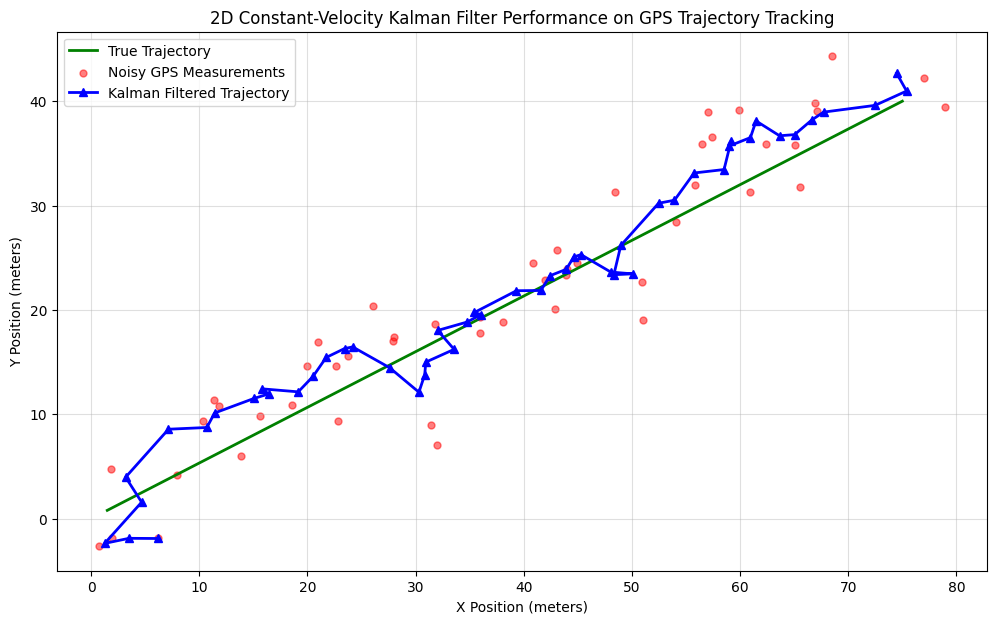

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def kalman_filter_2d_gps(y_meas, delta_t=1.0, q_var=0.05, r_var=5.0):
    """
    Filters a sequence of noisy 2D GPS position measurements.

    Parameters:
    - y_meas: array-like of shape (N, 2) containing [[x1, y1], [x2, y2], ...]
    - delta_t: time step between measurements
    - q_var: variance of the process noise (acceleration variance)
    - r_var: variance of the GPS measurement noise
    """
    y_meas = np.array(y_meas)
    N = len(y_meas)

    # 1. Initialize State Space Models Matrices (From Derivations)
    A = np.array([[1, 0, delta_t, 0],
                  [0, 1, 0, delta_t],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])

    G = np.array([[0.5 * delta_t**2, 0],
                  [0, 0.5 * delta_t**2],
                  [delta_t, 0],
                  [0, delta_t]])

    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])

    # Process noise covariance matrix
    Sigma_p = np.eye(2) * q_var
    Q = G @ Sigma_p @ G.T

    # Measurement noise covariance matrix
    R = np.eye(2) * r_var

    # 2. Filter Initialization
    # Start initial position at first measurement, zero initial velocity
    x_post = np.array([y_meas[0, 0], y_meas[0, 1], 0.0, 0.0])
    P_post = np.eye(4) * 10.0  # Initial uncertainty

    # Storage arrays for filtered trajectory
    filtered_states = np.zeros((N, 4))
    filtered_states[0] = x_post

    # 3. Kalman Filter Loop
    for k in range(1, N):
        # --- Predict Step ---
        x_prior = A @ x_post
        P_prior = A @ P_post @ A.T + Q

        # --- Update Step ---
        y_actual = y_meas[k]
        residual = y_actual - (H @ x_prior)
        S = H @ P_prior @ H.T + R

        # Compute Kalman Gain
        K = P_prior @ H.T @ np.linalg.inv(S)

        # Update State and Covariance
        x_post = x_prior + K @ residual
        P_post = (np.eye(4) - K @ H) @ P_prior

        filtered_states[k] = x_post

    return filtered_states

# ==========================================
# 4. Simulation & Verification Block
# ==========================================
# Generate a mock true trajectory (e.g., a boat or car moving steadily)
np.random.seed(24)
N_steps = 50
dt = 1.0

true_vx, true_vy = 1.5, 0.8
true_x = np.cumsum(np.ones(N_steps) * true_vx * dt)
true_y = np.cumsum(np.ones(N_steps) * true_vy * dt)
true_trajectory = np.column_stack((true_x, true_y))

# Add heavy GPS Gaussian noise
gps_noise_std = 3.5
noise = np.random.normal(0, gps_noise_std, size=(N_steps, 2))
noisy_gps_measurements = true_trajectory + noise

# Execute the implemented filter method
filtered_output = kalman_filter_2d_gps(noisy_gps_measurements, delta_t=dt, q_var=0.1, r_var=gps_noise_std**2)

# Plotting the Results
plt.figure(figsize=(12, 7))
plt.plot(true_trajectory[:, 0], true_trajectory[:, 1], 'g-', label='True Trajectory', lw=2)
plt.scatter(noisy_gps_measurements[:, 0], noisy_gps_measurements[:, 1], color='red', alpha=0.5, s=25, label='Noisy GPS Measurements')
plt.plot(filtered_output[:, 0], filtered_output[:, 1], 'b-^', label='Kalman Filtered Trajectory', lw=2)

plt.title('2D Constant-Velocity Kalman Filter Performance on GPS Trajectory Tracking')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()